In [17]:
# ============================================================
# AC-1: Data Handling Layer (Teacher + Student) - Final Version
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.signal import decimate
from tensorflow.keras.utils import Sequence

# ------------------------------------------------------------
# Path
# ------------------------------------------------------------
DATA_PATH = "/Volumes/Extreme SSD/stream_stead/output/stead_processed.npy"
CSV_PATH  = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv"

# ------------------------------------------------------------
# 1. Load metadata + label biner
# ------------------------------------------------------------
def load_labels():
    df = pd.read_csv(CSV_PATH, low_memory=False)
    categories = df["trace_category"].values

    labels = np.zeros(len(categories), dtype=np.int8)
    labels[(categories == "earthquake_local")] = 1
    labels[(categories == "earthquake_regional")] = 1

    return labels

# ------------------------------------------------------------
# 2. Load memmap (teacher input)
# ------------------------------------------------------------
def load_memmap():
    return np.memmap(DATA_PATH, dtype="float32", mode="r").reshape(-1, 6000, 3)

# ------------------------------------------------------------
# 3. Downsampling untuk student model (L0)
# ------------------------------------------------------------
def downsample_signal(x, factor=60):
    # 6000 sampel / 60 = 100 sampel
    return decimate(x, factor, axis=0, zero_phase=True)

# ------------------------------------------------------------
# 4. Dataset Loader (Teacher) - Keras Sequence
# ------------------------------------------------------------
class TeacherLoader(Sequence):
    def __init__(self, memmap, labels, indices, batch_size=32):
        self.memmap = memmap
        self.labels = labels
        self.indices = indices
        self.batch_size = batch_size

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        X = self.memmap[batch_idx]
        y = self.labels[batch_idx]
        return X, y

# ------------------------------------------------------------
# 5. Dataset Loader (Student) - Keras Sequence
# ------------------------------------------------------------
class StudentLoader(Sequence):
    def __init__(self, memmap, labels, indices, batch_size=32):
        self.memmap = memmap
        self.labels = labels
        self.indices = indices
        self.batch_size = batch_size

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        X_full = self.memmap[batch_idx]
        X_small = np.array([downsample_signal(x) for x in X_full])
        y = self.labels[batch_idx]
        return X_small, y

# ------------------------------------------------------------
# 6. Fungsi utama AC-1
# ------------------------------------------------------------
def build_ac1(batch_size=32):
    labels = load_labels()
    memmap = load_memmap()

    idx = np.arange(len(labels))
    train_idx, test_idx = train_test_split(idx, test_size=0.15, random_state=42)
    train_idx, val_idx  = train_test_split(train_idx, test_size=0.176, random_state=42)

    teacher_train = TeacherLoader(memmap, labels, train_idx, batch_size)
    teacher_val   = TeacherLoader(memmap, labels, val_idx, batch_size)
    teacher_test  = TeacherLoader(memmap, labels, test_idx, batch_size)

    student_train = StudentLoader(memmap, labels, train_idx, batch_size)
    student_val   = StudentLoader(memmap, labels, val_idx, batch_size)
    student_test  = StudentLoader(memmap, labels, test_idx, batch_size)

    return {
        "teacher_train": teacher_train,
        "teacher_val": teacher_val,
        "teacher_test": teacher_test,
        "student_train": student_train,
        "student_val": student_val,
        "student_test": student_test,
        "labels": labels
    }



In [18]:
ac1 = build_ac1(batch_size=32)


In [19]:
import tensorflow as tf
import json
import glob
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Teacher Model Architecture
# ------------------------------------------------------------
def build_teacher_model(input_shape=(6000, 3)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.Conv1D(256, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

# ------------------------------------------------------------
# 2. Save training history
# ------------------------------------------------------------
def save_history_json(history, filename="teacher_history.json"):
    hist = history.history
    with open(filename, "w") as f:
        json.dump(hist, f, indent=4)

# ------------------------------------------------------------
# 3. Plot training curves
# ------------------------------------------------------------
def plot_training_curves(history):
    hist = history.history

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist["accuracy"], label="Train Acc")
    plt.plot(hist["val_accuracy"], label="Val Acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4. Resume-Safe Training Function
# ------------------------------------------------------------
def train_teacher_resume(ac1, epochs=10, batch_size=32):

    teacher_train = ac1["teacher_train"]
    teacher_val   = ac1["teacher_val"]

    # --------------------------------------------------------
    # A. Cek checkpoint terbaru
    # --------------------------------------------------------
    ckpts = sorted(glob.glob("teacher_checkpoint_epoch_*.h5"))

    if len(ckpts) > 0:
        latest_ckpt = ckpts[-1]
        print(f"🔄 Melanjutkan training dari checkpoint: {latest_ckpt}")
        model = tf.keras.models.load_model(latest_ckpt)
    else:
        print("🚀 Tidak ada checkpoint. Memulai training dari awal.")
        model = build_teacher_model()

    # --------------------------------------------------------
    # B. Compile model
    # --------------------------------------------------------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall()]
    )

    # --------------------------------------------------------
    # C. Callback aman (checkpoint setiap epoch)
    # --------------------------------------------------------
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            "teacher_checkpoint_epoch_{epoch:02d}.h5",
            save_weights_only=False,
            save_freq="epoch"
        ),
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]

    # --------------------------------------------------------
    # D. Training
    # --------------------------------------------------------
    history = model.fit(
        teacher_train,
        validation_data=teacher_val,
        epochs=epochs,
        verbose=1,
        callbacks=callbacks
    )

    # --------------------------------------------------------
    # E. Save final model
    # --------------------------------------------------------
    model.save("teacher_model_final.h5")
    save_history_json(history, "teacher_history_resume.json")
    plot_training_curves(history)

    return model, history


🚀 Tidak ada checkpoint. Memulai training dari awal.


2026-03-05 14:52:22.299260: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-05 14:52:22.299455: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-03-05 14:52:22.299471: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-03-05 14:52:22.299709: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-05 14:52:22.299724: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/homebrew/Caskroom/miniforge/base/envs/seismic/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should

Epoch 1/10


2026-03-05 14:52:23.488023: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


27702/27702 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9678 - loss: 0.0950 - recall: 0.9816

...

27702/27702 ━━━━━━━━━━━━━━━━━━━━ 6275s 227ms/step - accuracy: 0.9977 - loss: 0.0078 - recall: 0.9988 - val_accuracy: 0.9977 - val_loss: 0.0091 - val_recall: 0.9980
Epoch 7/10
27702/27702 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9979 - loss: 0.0071 - recall: 0.9989

27702/27702 ━━━━━━━━━━━━━━━━━━━━ 5795s 209ms/step - accuracy: 0.9979 - loss: 0.0071 - recall: 0.9989 - val_accuracy: 0.9979 - val_loss: 0.0077 - val_recall: 0.9987
Epoch 8/10
27702/27702 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9981 - loss: 0.0066 - recall: 0.9990

27702/27702 ━━━━━━━━━━━━━━━━━━━━ 5062s 183ms/step - accuracy: 0.9981 - loss: 0.0066 - recall: 0.9990 - val_accuracy: 0.9981 - val_loss: 0.0071 - val_recall: 0.9988
Epoch 9/10
27702/27702 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9982 - loss: 0.0059 - recall: 0.9990

27702/27702 ━━━━━━━━━━━━━━━━━━━━ 4537s 164ms/step - accuracy: 0.9983 - loss: 0.0060 - recall: 0.9990 - val_accuracy: 0.9977 - val_loss: 0.0085 - val_recall: 0.9983
Epoch 10/10
27702/27702 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9984 - loss: 0.0056 - recall: 0.9991

27702/27702 ━━━━━━━━━━━━━━━━━━━━ 1774s 64ms/step - accuracy: 0.9984 - loss: 0.0056 - recall: 0.9991 - val_accuracy: 0.9979 - val_loss: 0.0078 - val_recall: 0.9989


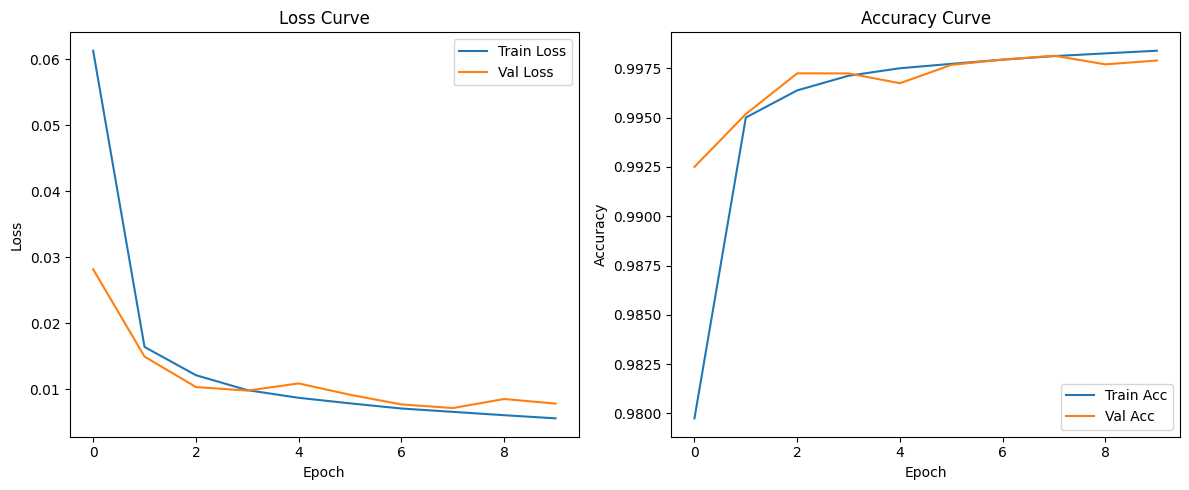

In [21]:
model, history = train_teacher_resume(ac1, epochs=10)


In [4]:
# --- [1] Import library inti ---
import tensorflow as tf
import numpy as np
from tqdm import tqdm
# --- [2] Load teacher model ---
TEACHER_MODEL_PATH = "teacher_model_final.h5"

print(f"[INFO] Loading teacher model from: {TEACHER_MODEL_PATH}")
teacher_model = tf.keras.models.load_model(TEACHER_MODEL_PATH)
# --- [3] Load memmap 3-komponen ---
DATA_PATH = "/Volumes/Extreme SSD/stream_stead/output/stead_processed.npy"

print("[INFO] Loading memmap 3-komponen...")
X_ac2 = np.memmap(DATA_PATH, dtype="float32", mode="r").reshape(-1, 6000, 3)

print("[INFO] Memmap loaded successfully.")
print("Shape:", X_ac2.shape)
# --- [4] Build embedding_model & logits_model ---

# Cari layer global pooling
embedding_layer = None
for layer in teacher_model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.GlobalAveragePooling1D):
        embedding_layer = layer
        break

if embedding_layer is None:
    raise ValueError("GlobalAveragePooling1D layer not found.")

print(f"[INFO] Using embedding layer: {embedding_layer.name}")

# Model embedding
embedding_model = tf.keras.Model(
    inputs=teacher_model.input,
    outputs=embedding_layer.output
)

# Model logits (pre-sigmoid)
logits_layer = teacher_model.layers[-1]
logits_model = tf.keras.Model(
    inputs=teacher_model.input,
    outputs=logits_layer(embedding_layer.output)
)
# --- [5] Ekstraksi embedding/logits ---

BATCH_SIZE = 256
num_samples = X_ac2.shape[0]
num_batches = int(np.ceil(num_samples / BATCH_SIZE))

# Tentukan dimensi embedding
test_batch = embedding_model(X_ac2[:1])
embedding_dim = test_batch.shape[-1]

# Siapkan array output
embeddings = np.zeros((num_samples, embedding_dim), dtype=np.float32)
logits     = np.zeros((num_samples, 1), dtype=np.float32)

print(f"[INFO] Starting extraction: {num_samples} samples, {num_batches} batches.")

for b in tqdm(range(num_batches), desc="Extracting", ncols=80):
    start = b * BATCH_SIZE
    end   = min((b + 1) * BATCH_SIZE, num_samples)

    X_batch = X_ac2[start:end]  # langsung dari memmap

    emb_batch = embedding_model.predict(X_batch, verbose=0)
    log_batch = logits_model.predict(X_batch, verbose=0)

    embeddings[start:end] = emb_batch
    logits[start:end]     = log_batch

print("[INFO] Extraction finished.")
# --- [6] Save output ---

np.save("embeddings_ac2.npy", embeddings)
np.save("logits_ac2.npy", logits)

print("[DONE] Saved embeddings_ac2.npy & logits_ac2.npy")


[INFO] Loading teacher model from: teacher_model_final.h5


2026-03-06 14:56:41.618984: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-06 14:56:41.619039: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-03-06 14:56:41.619051: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-03-06 14:56:41.619240: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-06 14:56:41.619254: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[INFO] Loading memmap 3-komponen...
[INFO] Memmap loaded successfully.
Shape: (1265657, 6000, 3)
[INFO] Using embedding layer: global_average_pooling1d
[INFO] Starting extraction: 1265657 samples, 4944 batches.


Extracting: 100%|███████████████████████████| 4944/4944 [28:58<00:00,  2.84it/s]


[INFO] Extraction finished.
[DONE] Saved embeddings_ac2.npy & logits_ac2.npy


In [ ]:
# ---- Mulai AC-2: Student Model Training dengan Knowledge Distillation ----

In [6]:
# --- Regenerate labels_ac2.npy ---

import numpy as np
import pandas as pd

CSV_PATH  = "/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv"

def load_labels():
    df = pd.read_csv(CSV_PATH, low_memory=False)
    categories = df["trace_category"].values

    labels = np.zeros(len(categories), dtype=np.int8)
    labels[(categories == "earthquake_local")] = 1
    labels[(categories == "earthquake_regional")] = 1

    return labels

print("[INFO] Loading labels from metadata...")
labels = load_labels()

print("[INFO] Saving labels_ac2.npy...")
np.save("labels_ac2.npy", labels)

print("[DONE] labels_ac2.npy saved successfully.")
print("Shape:", labels.shape)


[INFO] Loading labels from metadata...
[INFO] Saving labels_ac2.npy...
[DONE] labels_ac2.npy saved successfully.
Shape: (1265657,)


In [7]:
# --- [1] Import & load data distillation ---
import tensorflow as tf
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split

# Path file distillation
LOGITS_PATH = "logits_ac2.npy"
LABELS_PATH = "labels_ac2.npy"  # pastikan sudah kamu simpan sebelumnya

print("[INFO] Loading logits & labels...")
teacher_logits = np.load(LOGITS_PATH)   # shape: (N, 1)
labels        = np.load(LABELS_PATH)    # shape: (N,)

print("[INFO] teacher_logits:", teacher_logits.shape)
print("[INFO] labels       :", labels.shape)


[INFO] Loading logits & labels...
[INFO] teacher_logits: (1265657, 1)
[INFO] labels       : (1265657,)


In [8]:
# --- [2] StudentLoader AC-3 (sinkron dengan logits) ---
from scipy.signal import decimate
from tensorflow.keras.utils import Sequence

DATA_PATH = "/Volumes/Extreme SSD/stream_stead/output/stead_processed.npy"

def downsample_signal(x, factor=60):
    return decimate(x, factor, axis=0, zero_phase=True)  # 6000 -> 100

class StudentDistillLoader(Sequence):
    def __init__(self, memmap, labels, teacher_logits, indices, batch_size=64):
        self.memmap = memmap
        self.labels = labels
        self.teacher_logits = teacher_logits
        self.indices = indices
        self.batch_size = batch_size

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]

        X_full = self.memmap[batch_idx]  # (B, 6000, 3)
        X_small = np.array([downsample_signal(x) for x in X_full])  # (B, 100, 3)

        y_true   = self.labels[batch_idx]          # (B,)
        y_logits = self.teacher_logits[batch_idx]  # (B, 1)

        return X_small, {"y_true": y_true, "y_teacher": y_logits}


In [9]:
# --- [3] Split index & build loader ---

# Load memmap 3-komponen
memmap = np.memmap(DATA_PATH, dtype="float32", mode="r").reshape(-1, 6000, 3)
N = labels.shape[0]
idx = np.arange(N)

train_idx, test_idx = train_test_split(idx, test_size=0.15, random_state=42)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.176, random_state=42)

BATCH_SIZE = 64

student_train = StudentDistillLoader(memmap, labels, teacher_logits, train_idx, BATCH_SIZE)
student_val   = StudentDistillLoader(memmap, labels, teacher_logits, val_idx,   BATCH_SIZE)
student_test  = StudentDistillLoader(memmap, labels, teacher_logits, test_idx,  BATCH_SIZE)

print("[INFO] StudentDistillLoader ready.")
print("Train batches:", len(student_train))
print("Val   batches:", len(student_val))
print("Test  batches:", len(student_test))


[INFO] StudentDistillLoader ready.
Train batches: 13851
Val   batches: 2958
Test  batches: 2966


In [21]:
# --- [4] Arsitektur student AC-3 ---

from tensorflow.keras import layers, Model

def build_student_model(input_shape=(100, 3)):
    inputs = layers.Input(shape=input_shape, name="student_input")

    x = layers.Conv1D(32, 5, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="student_output")(x)

    model = Model(inputs=inputs, outputs=outputs, name="student_ac3")
    return model

student_model = build_student_model()
student_model.summary()


Model: "student_ac3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ student_input (InputLayer)      │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ student_output (Dense)          │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,841 (171.25 KB)

 Trainable params: 43,841 (171.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# --- [5] Loss distillation gabungan ---

bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
kld = tf.keras.losses.KLDivergence()

T = 4.0
alpha = 0.9
beta  = 0.1

optimizer = tf.keras.optimizers.Adam(3e-4)


bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
kld = tf.keras.losses.KLDivergence()

@tf.function
def distillation_loss(y_true, y_teacher_logits, y_student):
    y_true = tf.cast(y_true, tf.float32)

    # BCE ke label asli
    loss_ce = bce(y_true, y_student)

    # Soft target teacher
    teacher_prob = tf.nn.sigmoid(y_teacher_logits / T)
    student_prob = tf.nn.sigmoid(tf.math.log(y_student + 1e-7) / T)

    loss_kd = kld(teacher_prob, student_prob)

    return alpha * loss_ce + beta * loss_kd




In [28]:
# --- [6] Training loop student AC-3 dengan progress bar ---

optimizer = tf.keras.optimizers.Adam(2e-4)

@tf.function
def train_step(x, y_true, y_teacher_logits):
    with tf.GradientTape() as tape:
        y_pred = student_model(x, training=True)
        loss = distillation_loss(y_true, y_teacher_logits, y_pred)
    grads = tape.gradient(loss, student_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, student_model.trainable_variables))
    return loss

@tf.function
def val_step(x, y_true, y_teacher_logits):
    y_pred = student_model(x, training=False)
    loss = distillation_loss(y_true, y_teacher_logits, y_pred)
    return loss

START_EPOCH = 6
EPOCHS = 10

for epoch in range(START_EPOCH, EPOCHS+1):
    print(f"\n[Epoch {epoch}/{EPOCHS}]")

    # --- Train ---
    train_losses = []
    for i in tqdm(range(len(student_train)), desc="Train", ncols=80):
        x_batch, y_dict = student_train[i]
        loss = train_step(
            x_batch,
            y_dict["y_true"],
            y_dict["y_teacher"]
        )
        train_losses.append(loss.numpy())

    # --- Val ---
    val_losses = []
    for i in tqdm(range(len(student_val)), desc="Val  ", ncols=80):
        x_batch, y_dict = student_val[i]
        loss = val_step(
            x_batch,
            y_dict["y_true"],
            y_dict["y_teacher"]
        )
        val_losses.append(loss.numpy())

    print(f"[INFO] Train loss: {np.mean(train_losses):.4f} | Val loss: {np.mean(val_losses):.4f}")



[Epoch 6/10]


Val  : 100%|████████████████████████████████| 2958/2958 [05:54<00:00,  8.34it/s]


[INFO] Train loss: 0.2037 | Val loss: 0.2075

[Epoch 7/10]


Val  : 100%|████████████████████████████████| 2958/2958 [05:08<00:00,  9.58it/s]


[INFO] Train loss: 0.1910 | Val loss: 0.2017

[Epoch 8/10]


...

[INFO] Train loss: 0.1850 | Val loss: 0.1933

[Epoch 9/10]


Val  : 100%|████████████████████████████████| 2958/2958 [06:01<00:00,  8.18it/s]


[INFO] Train loss: 0.1820 | Val loss: 0.1944

[Epoch 10/10]


Val  : 100%|████████████████████████████████| 2958/2958 [06:02<00:00,  8.17it/s]

[INFO] Train loss: 0.1799 | Val loss: 0.1877


In [ ]:
# AC 3 selesai, selanjutnya penyimpanan

In [35]:
whos


Variable               Type                      Data/Info
----------------------------------------------------------
BATCH_SIZE             int                       64
CSV_PATH               str                       /Volumes/Extreme SSD/stre<...>tead/data_stead/merge.csv
DATA_PATH              str                       /Volumes/Extreme SSD/stre<...>utput/stead_processed.npy
EPOCHS                 int                       10
LABELS_PATH            str                       labels_ac2.npy
LOGITS_PATH            str                       logits_ac2.npy
MODEL_DIR              str                       AC3_Model/model
Model                  type                      <class 'keras.src.models.model.Model'>
N                      int                       1265657
SAVE_DIR               str                       AC3_Model
START_EPOCH            int                       6
Sequence               type                      <class 'keras.src.trainer<...>taset_adapter.PyDataset'>
StudentDistillL

In [39]:
import os

SAVE_DIR = "AC3_Model"
MODEL_DIR = os.path.join(SAVE_DIR, "model")
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Simpan format Keras baru
student_model.save(os.path.join(MODEL_DIR, "ac3_model.keras"))

# 2. Simpan bobot H5 (format baru Keras 3)
student_model.save_weights(os.path.join(MODEL_DIR, "ac3.weights.h5"))

# 3. Export SavedModel
student_model.export(os.path.join(MODEL_DIR, "saved_model"))

print("Model AC-3 berhasil disimpan dalam format .keras, .weights.h5, dan SavedModel.")


INFO:tensorflow:Assets written to: AC3_Model/model/saved_model/assets


INFO:tensorflow:Assets written to: AC3_Model/model/saved_model/assets


Saved artifact at 'AC3_Model/model/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 3), dtype=tf.float32, name='student_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  16278714880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284635680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284635152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284638496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284639552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284566976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284567152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284578064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284580528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16284579296: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model AC-3 berhasil disimpan dalam format .keras,

In [16]:
import os, json

SAVE_DIR = "AC3_Model"
PRE_DIR = os.path.join(SAVE_DIR, "preprocessing")
os.makedirs(PRE_DIR, exist_ok=True)

preprocessing_config = {
    "mean": 0.0,
    "std": 1.0,
    "window_size": 100,
    "stride": 1,
    "trim_length": 100,
    "channels": 3,
    "note": "Placeholder config. Update mean/std jika sudah dihitung."
}

with open(os.path.join(PRE_DIR, "preprocessing_config.json"), "w") as f:
    json.dump(preprocessing_config, f, indent=4)

print("Preprocessing config dibuat.")


Preprocessing config dibuat.
